# Miniproject 1 — Architecture 1: Underfitting CNN

**Team Members:** Aurel Köppel, Yves Fricker

**Course:** Applications of AI (AiAp), OST, Spring 2026

---

In this notebook we define and train a **very simple CNN** for multi-class image classification on the Animals-10 dataset. The goal is to demonstrate **underfitting**: the model is too simple to learn the patterns in the data.

## 1. Imports and Setup

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Set Keras backend to TensorFlow
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers

# Import our shared helper functions
from helpers import (
    load_animals10,
    split_data,
    plot_learning_curves,
    plot_confusion_matrices,
    print_classification_metrics,
)

print(f"Keras version: {keras.__version__}")
print(f"Backend: {keras.backend.backend()}")

Keras version: 3.13.2
Backend: tensorflow


## 2. Dataset: Animals-10

**Source:** [Animals-10 on Kaggle](https://www.kaggle.com/datasets/alessiocorrado99/animals10)  
**Author:** Alessio Corrado  
**License:** GPL-2  

The Animals-10 dataset contains images of 10 different animal categories. The folder names are in Italian. We use the following mapping:

| Italian | English |
|---|---|
| cane | dog |
| cavallo | horse |
| elefante | elephant |
| farfalla | butterfly |
| gallina | chicken |
| gatto | cat |
| mucca | cow |
| pecora | sheep |
| ragno | spider |
| scoiattolo | squirrel |

### Preprocessing Steps

1. **Resize:** All images are resized to **64×64 pixels** to keep training fast.
2. **Normalize:** Pixel values are scaled from [0, 255] to **[0, 1]** by dividing by 255.
3. **Balance:** Each class is limited to **1000 samples**, except for "elephant" which is reduced to **150 samples** to simulate a class imbalance.
4. **Split:** 30% test set (locked), 70% train+validation.

In [2]:
import kagglehub

# Download dataset automatically (cached after first download)
path = kagglehub.dataset_download("alessiocorrado99/animals10")
DATA_DIR = os.path.join(path, "raw-img")

print(f"Dataset path: {DATA_DIR}")

# Load the dataset
X, y, class_names = load_animals10(
    data_dir=DATA_DIR,
    img_size=64,
    samples_per_class=1000,
    reduced_class="elefante",
    reduced_count=150,
    seed=42,
)

print(f"\nImage shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Classes: {class_names}")
print(f"Value range: [{X.min():.2f}, {X.max():.2f}]")

Dataset path: C:\Users\Aurel\.cache\kagglehub\datasets\alessiocorrado99\animals10\versions\2\raw-img
  Loaded 1000 images for class 'dog' (folder: cane)
  Loaded 1000 images for class 'horse' (folder: cavallo)
  Loaded 150 images for class 'elephant' (folder: elefante)
  Loaded 1000 images for class 'butterfly' (folder: farfalla)
  Loaded 1000 images for class 'chicken' (folder: gallina)
  Loaded 1000 images for class 'cat' (folder: gatto)
  Loaded 1000 images for class 'cow' (folder: mucca)
  Loaded 1000 images for class 'sheep' (folder: pecora)
  Loaded 1000 images for class 'spider' (folder: ragno)
  Loaded 1000 images for class 'squirrel' (folder: scoiattolo)

Total: 9150 images, 10 classes

Image shape: (9150, 64, 64, 3)
Labels shape: (9150,)
Classes: ['dog', 'horse', 'elephant', 'butterfly', 'chicken', 'cat', 'cow', 'sheep', 'spider', 'squirrel']
Value range: [0.00, 1.00]


## 3. Data Split

We split the data into:
- **70% Train + Validation:** Used for training and monitoring.
- **30% Test:** Locked away — only used at the very end in Notebook 3.

The split is **stratified** to preserve the class distribution in both sets.

In [4]:
X_trainval, X_test, y_trainval, y_test = split_data(X, y, test_size=0.3, random_state=42)

print(f"\nTrain+Val shape: {X_trainval.shape}")
print(f"Test shape:      {X_test.shape}")

Train+Val: 6405 samples
Test:      2745 samples (locked away)

Train+Val shape: (6405, 64, 64, 3)
Test shape:      (2745, 64, 64, 3)


## 4. Exploratory Data Analysis (EDA)

Before building any model, we need to understand our data.

### 4.1 Class Distribution

We visualize how many samples we have per class. Due to our intentional imbalance, the "elephant" class has only 150 samples.

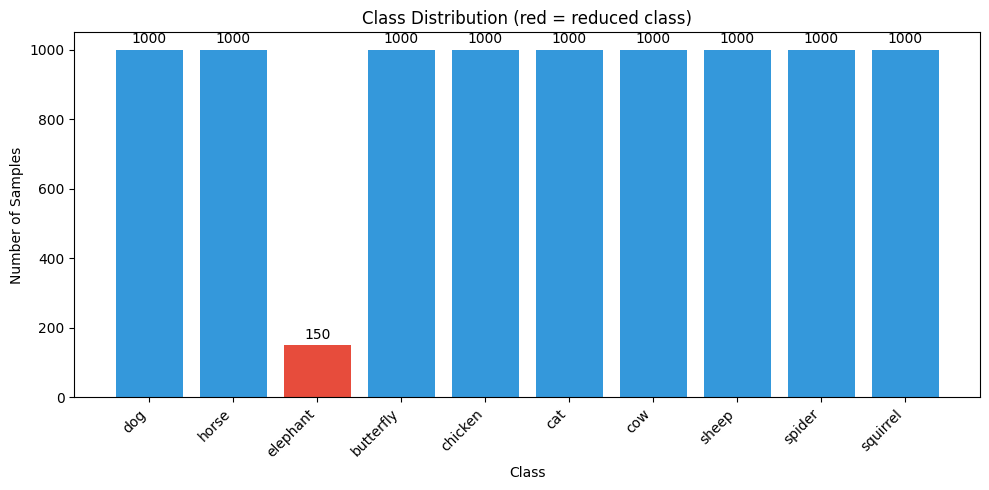

Dataset is IMBALANCED: 'elephant' has only 150 samples, all others have 1000.
Total samples: 9150


In [5]:
# Count samples per class
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(10, 5))
colors = ['#e74c3c' if class_names[i] == 'elephant' else '#3498db' for i in unique]
bars = plt.bar([class_names[i] for i in unique], counts, color=colors)
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution (red = reduced class)")
plt.xticks(rotation=45, ha="right")

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"Dataset is IMBALANCED: 'elephant' has only 150 samples, all others have 1000.")
print(f"Total samples: {len(y)}")

### 4.2 Sample Images

Let's look at a few example images from each class to get a visual impression of the data.

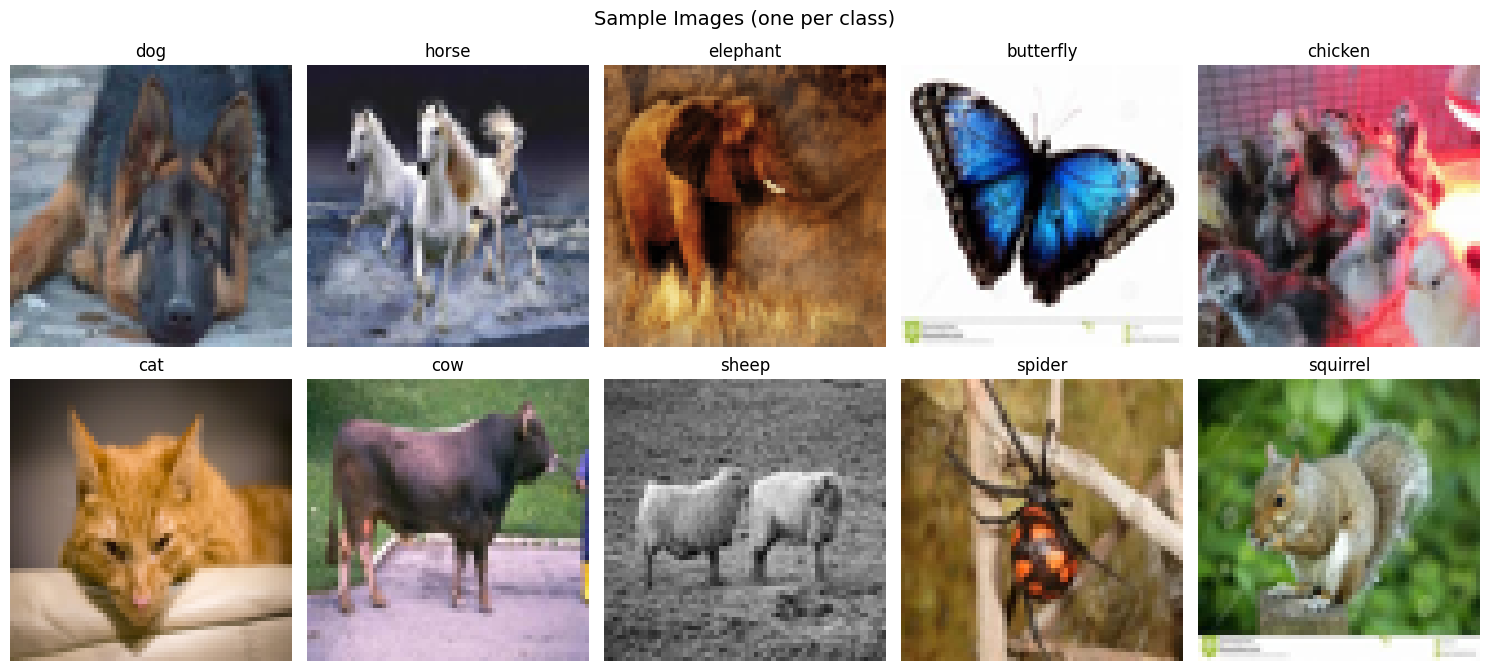

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Sample Images (one per class)", fontsize=14)

for idx, ax in enumerate(axes.flat):
    if idx < len(class_names):
        # Find first image of this class
        class_indices = np.where(y == idx)[0]
        sample_idx = class_indices[0]
        ax.imshow(X[sample_idx])
        ax.set_title(class_names[idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

### 4.3 Image Statistics

We verify that the images are correctly normalized and check basic statistics.

In [7]:
print(f"Image dtype:     {X.dtype}")
print(f"Image shape:     {X.shape[1:]} (height x width x channels)")
print(f"Pixel min value: {X.min():.4f}")
print(f"Pixel max value: {X.max():.4f}")
print(f"Pixel mean:      {X.mean():.4f}")
print(f"Pixel std:       {X.std():.4f}")
print(f"\n-> Values are in [0, 1] — normalization is correct.")

Image dtype:     float32
Image shape:     (64, 64, 3) (height x width x channels)
Pixel min value: 0.0000
Pixel max value: 1.0000
Pixel mean:      0.4702
Pixel std:       0.2648

-> Values are in [0, 1] — normalization is correct.


## 5. Model Definition — Simple CNN (Underfitting)

We build a very simple CNN with only **3 trainable layers** and approximately **1700 trainable parameters**.

**Architecture:**
- `Conv2D(4 filters, 3×3, stride=2)` — only 4 feature maps, very limited capacity
- `MaxPooling2D(2×2)` — reduces spatial dimensions
- `Conv2D(8 filters, 3×3, stride=2)` — slightly more features, but still very few
- `MaxPooling2D(2×2)` — further reduction
- `Flatten` → `Dense(10, softmax)` — output layer for 10 classes

**Why this will underfit:**
- Very few filters (4 and 8) means the network can only detect a handful of simple patterns.
- With ~1700 parameters, the model simply does not have enough capacity to learn the complex visual features needed to distinguish 10 animal classes.

**Note on stride:** We use `stride=2` combined with `MaxPooling` to aggressively reduce spatial dimensions. This keeps the parameter count very low. We avoid `stride > kernel_size` because that would skip pixels entirely, losing information between the filter positions.

In [8]:
NUM_CLASSES = len(class_names)
IMG_SIZE = 64

model = keras.Sequential([
    # Input layer
    keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First convolutional block: 4 filters, stride=2 to reduce dimensions quickly
    layers.Conv2D(4, (3, 3), strides=2, padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 64 -> 32 (stride) -> 16 (pool)

    # Second convolutional block: 8 filters, stride=2
    layers.Conv2D(8, (3, 3), strides=2, padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),  # 16 -> 8 (stride) -> 4 (pool)

    # Flatten and classify
    layers.Flatten(),  # 4 * 4 * 8 = 128
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 4)           │             112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 16, 16, 4)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 8, 8, 8)             │             296 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 8)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,698 (6.63 KB)

 Trainable params: 1,698 (6.63 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Verify parameter count
total_params = model.count_params()
print(f"\nTotal trainable parameters: {total_params}")
print(f"Requirement: <= ~2000 parameters")
assert total_params <= 2000, f"Too many parameters: {total_params}"


Total trainable parameters: 1698
Requirement: <= ~2000 parameters


## 6. Compile and Train

We use:
- **Loss function:** `sparse_categorical_crossentropy` — suited for integer labels and multi-class classification.
- **Optimizer:** `adam` — adaptive learning rate, works well as a default.
- **Metric:** `accuracy` — easy to interpret, fraction of correct predictions.
- **Validation split:** 20% of the train+val data is used for validation during training.

We train for **50 epochs** to give the model enough time to converge.

In [10]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(
    X_trainval,
    y_trainval,
    epochs=50,
    batch_size=32,
    validation_split=0.2,  # 20% of train+val data used for validation
    verbose=1,
)

Epoch 1/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1553 - loss: 2.2362 - val_accuracy: 0.1585 - val_loss: 2.1917
Epoch 2/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2049 - loss: 2.1436 - val_accuracy: 0.2053 - val_loss: 2.1176
Epoch 3/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2508 - loss: 2.0599 - val_accuracy: 0.2529 - val_loss: 2.0582
Epoch 4/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2697 - loss: 1.9967 - val_accuracy: 0.2763 - val_loss: 2.0062
Epoch 5/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2894 - loss: 1.9541 - val_accuracy: 0.2779 - val_loss: 1.9899
Epoch 6/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3041 - loss: 1.9194 - val_accuracy: 0.3013 - val_loss: 1.9524
Epoch 7/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3205 - loss: 1.8883 - val_accuracy: 0.3138 - val_loss: 1.9409
Epoch 8/50
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3335 - loss: 1.8648 - val_accuracy: 0.

## 7. Learning Curves

We plot the training and validation loss/accuracy over the epochs.

**Expected behavior for underfitting:**
- Both training and validation curves are **very similar** (small gap).
- The accuracy converges to a **relatively low value** — the model cannot learn the task well.
- The loss plateaus at a **high value** — the model is not complex enough to reduce it further.

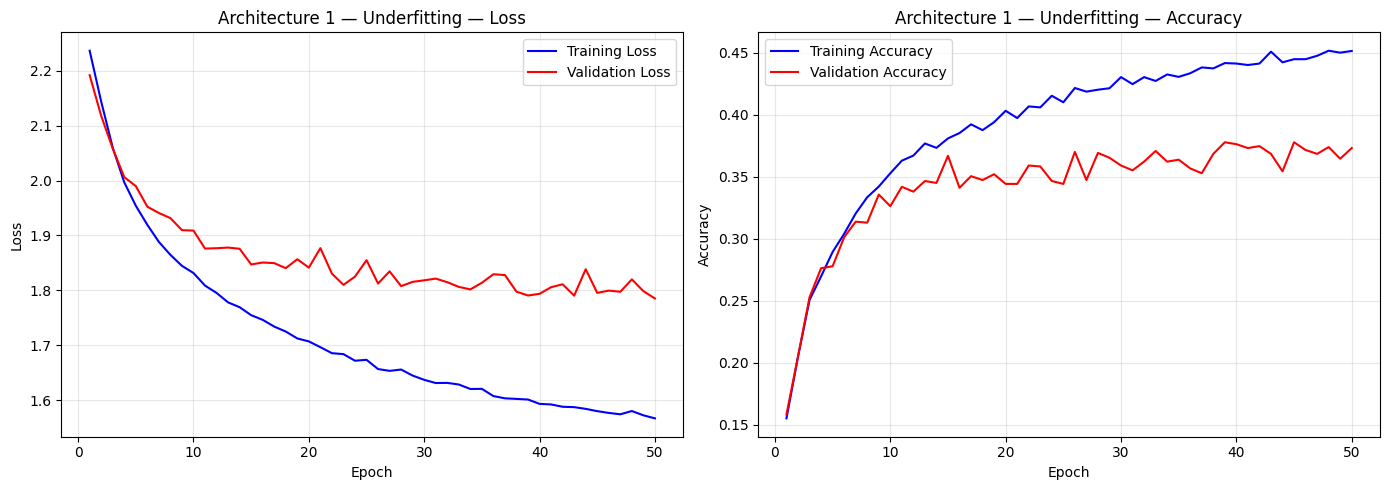

In [11]:
plot_learning_curves(history, title="Architecture 1 — Underfitting")

## 8. Confusion Matrices

We compute predictions on the **validation data** and plot 4 confusion matrices with different normalization modes:

1. **Absolute counts** — raw number of predictions per cell.
2. **Normalized by true label (rows)** — shows recall per class.
3. **Normalized by predicted label (columns)** — shows precision per class.
4. **Normalized by total samples** — shows overall distribution.

In [12]:
# Split train+val data the same way Keras does with validation_split=0.2
# Keras takes the LAST 20% as validation
val_split = int(len(X_trainval) * 0.8)
X_val = X_trainval[val_split:]
y_val = y_trainval[val_split:]

# Get predictions
y_pred_probs = model.predict(X_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"Validation set size: {len(X_val)}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Validation set size: 1281


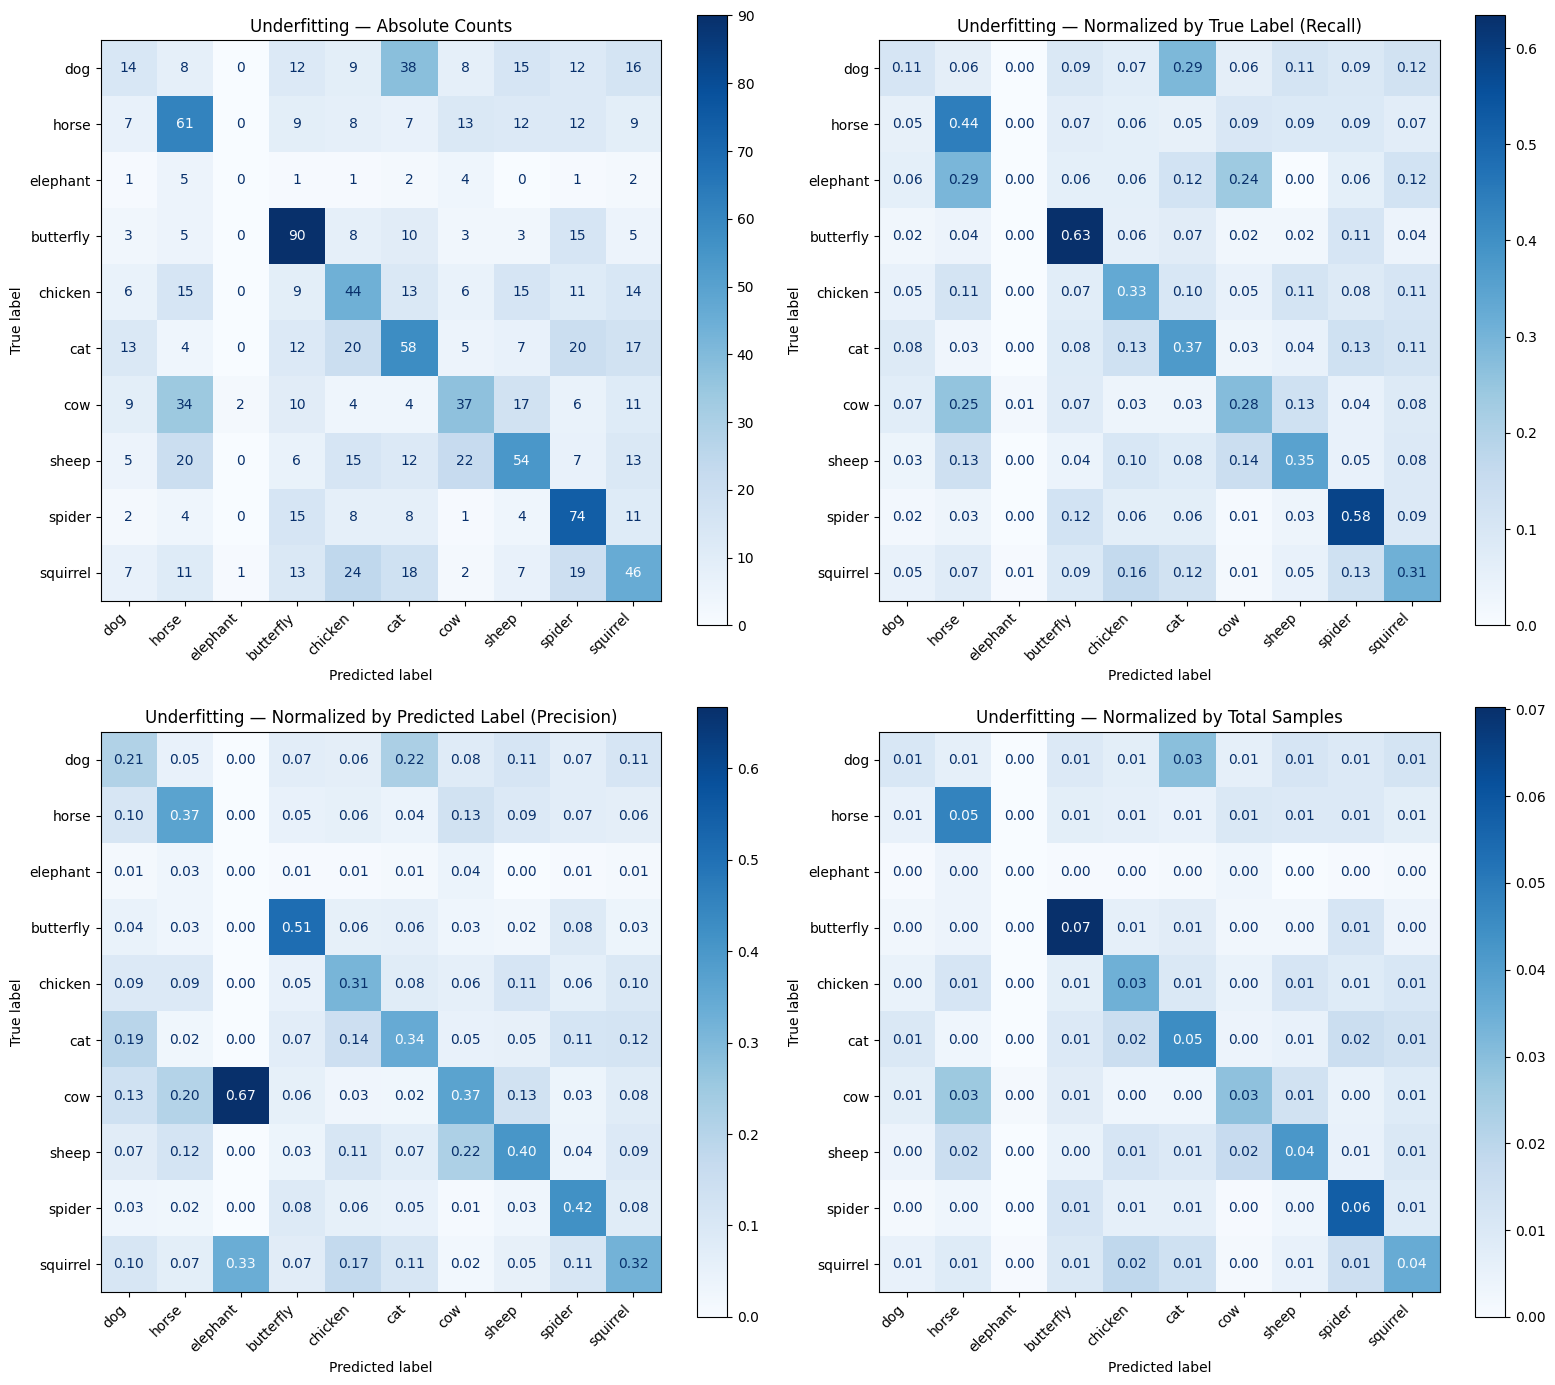

In [13]:
plot_confusion_matrices(y_val, y_pred, class_names, title_prefix="Underfitting — ")

## 9. Classification Metrics

We compute **Precision**, **Recall**, and **F1-score** for each class:

- **Precision** = TP / (TP + FP) — Of all samples predicted as class X, how many were correct?
- **Recall** = TP / (TP + FN) — Of all actual class X samples, how many were found?
- **F1-score** = 2 × (Precision × Recall) / (Precision + Recall) — Harmonic mean of Precision and Recall.

In [15]:
print_classification_metrics(y_val, y_pred, class_names)

Classification Report:
              precision    recall  f1-score   support

         dog      0.209     0.106     0.141       132
       horse      0.365     0.442     0.400       138
    elephant      0.000     0.000     0.000        17
   butterfly      0.508     0.634     0.564       142
     chicken      0.312     0.331     0.321       133
         cat      0.341     0.372     0.356       156
         cow      0.366     0.276     0.315       134
       sheep      0.403     0.351     0.375       154
      spider      0.418     0.583     0.487       127
    squirrel      0.319     0.311     0.315       148

    accuracy                          0.373      1281
   macro avg      0.324     0.340     0.327      1281
weighted avg      0.356     0.373     0.360      1281



## 10. Discussion

### Observations:

1. **Underfitting confirmed:** The training and validation curves are very close together, both converging to a relatively low accuracy. This is the classic signature of an underfitting model.

2. **Low capacity:** With only ~1700 parameters and just 4 / 8 filters, the network can only detect a very limited set of simple patterns (edges, basic textures). This is far too few to distinguish 10 different animal classes.

3. **Imbalanced class impact:** The "elephant" class (150 samples) likely has worse metrics than the other classes. With such a simple model, the network may ignore this minority class entirely.

4. **Confusion matrix insights:** We expect to see many off-diagonal entries, indicating that the model confuses many classes with each other.

### Conclusion:

This simple model is **too simple** for the task. The next step is to increase the model complexity (more layers, more filters, more parameters) to see if we can learn the patterns — at the risk of overfitting.